# Bilateral 2 towers LSTM Model over out timeseries data
- Add hyperparameter tunning posibilities


In [1]:
import os
# Make sure XLA is OFF (Metal doesn't support XLA/JIT)
# os.environ.pop("TF_XLA_FLAGS", None)
# os.environ.pop("XLA_FLAGS", None)
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"


import tensorflow as tf
# tf.config.optimizer.set_jit(False)
print("GPUs:", tf.config.list_physical_devices("GPU"))


import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score
)

import kineticstoolkit as ktk

import random
import pickle
import json
from typing import Tuple

from tensorflow import keras
import keras_tuner as kt
from tensorflow.keras import layers as L, models as M, Input, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy

from core.matlab_data_loader import MatlabDataLoader
from core.processing import preprocess_features
from core.timeseries import plot_compare_features, plot_all_features_overlay, bilateral_to_unilateral, split_unilateral
from core.evaluation import model_test_summary, BilateralPredictor, pick_threshold
from core.tunning import MetaHyperModel, ModelLoader, summarize_best_N_models


from pathlib import Path
import core.constants as c

RANDOM_STATE = 42
RANDOM_STATE_2 = 6
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Optimization for M4
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Notebook configuration

- **SAVE_MODEL**  
  - `True`: Will run and save this iteration of the model.  
  - `False`: Will load the model from the results folder.

- **SAVE_DATA**  
  - `True`: Will save the train, test, and validation sets as npz files.  
  - `False`: Will load the data from the results folder.

- **USE_TENSORBOARD**  
  - `True`: Will use TensorBoard to visualize the training process.
  - `False`: Will not use TensorBoard.

- **MODEL_NAME**  
  - The name of the model.

- **MODEL_RESULTS_FOLDER**  
  - The folder where the model results will be saved.

In [2]:
MODEL_NAME = "bi_tt_bilstm-v8_final"
MODEL_RESULTS_FOLDER = Path(c.RICKD_MODELS_FOLDER)/ "deep_learning" / MODEL_NAME
MODEL_RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Model results folder: {MODEL_RESULTS_FOLDER}")

Model results folder: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final


In [3]:
SAVE_MODEL = True
SAVE_DATA = False
USE_TENSORBOARD = False

print(f"SAVE_MODEL: {SAVE_MODEL}")
print(f"SAVE_DATA: {SAVE_DATA}")
print(f"USE_TENSORBOARD: {USE_TENSORBOARD}")

SAVE_MODEL: True
SAVE_DATA: False
USE_TENSORBOARD: False


## Load Input Data

In [4]:
timeseries_folder = Path(c.RICKD_PROCESSED_DATA_FOLDER) / 'timeseries'

all_sessions_matrix = np.load(timeseries_folder / 'timeseries_mean_matrix.npy')
with open(timeseries_folder / 'timeseries_mean_channels.json', 'r') as f:
    channels = json.load(f)
with open(timeseries_folder / 'timeseries_mean_sessions.json', 'r') as f:
    valid_session_ids = json.load(f)

# Edge case for subject created during DQ:
valid_session_ids = [
    '300375_20140502T074159' if sid == '200375_20140502T074159' else sid
    for sid in valid_session_ids
]

print("Shape of the timeseries matrix: ", all_sessions_matrix.shape)
print("Number of channels: ", len(channels))
print("Number of sessions: ", len(valid_session_ids))

for channel in channels:
    print(channel)

Shape of the timeseries matrix:  (1813, 101, 60)
Number of channels:  60
Number of sessions:  1813
L_ankle_angle_X
L_ankle_angle_Y
L_ankle_angle_Z
L_ankle_velocity_X
L_ankle_velocity_Y
L_ankle_velocity_Z
L_foot_angle_X
L_foot_angle_Y
L_foot_angle_Z
L_foot_velocity_X
L_foot_velocity_Y
L_foot_velocity_Z
L_hip_angle_X
L_hip_angle_Y
L_hip_angle_Z
L_hip_velocity_X
L_hip_velocity_Y
L_hip_velocity_Z
L_knee_angle_X
L_knee_angle_Y
L_knee_angle_Z
L_knee_velocity_X
L_knee_velocity_Y
L_knee_velocity_Z
R_ankle_angle_X
R_ankle_angle_Y
R_ankle_angle_Z
R_ankle_velocity_X
R_ankle_velocity_Y
R_ankle_velocity_Z
R_foot_angle_X
R_foot_angle_Y
R_foot_angle_Z
R_foot_velocity_X
R_foot_velocity_Y
R_foot_velocity_Z
R_hip_angle_X
R_hip_angle_Y
R_hip_angle_Z
R_hip_velocity_X
R_hip_velocity_Y
R_hip_velocity_Z
R_knee_angle_X
R_knee_angle_Y
R_knee_angle_Z
R_knee_velocity_X
R_knee_velocity_Y
R_knee_velocity_Z
L_pelvis_angle_X
L_pelvis_angle_Y
L_pelvis_angle_Z
L_pelvis_velocity_X
L_pelvis_velocity_Y
L_pelvis_velocity_

In [5]:
loader = MatlabDataLoader()

session_data = loader.get_session_data_full_cleaned().set_index("id")
metadata_columns = ["is_injured", "sub_id"]
# Filter session_data to only include valid_session_ids and preserve their order
session_data = session_data.loc[session_data.index.intersection(valid_session_ids)]
session_data = session_data.reindex(valid_session_ids)
session_data

,sub_id,datestring,filename,speed_r,age,Height,Weight,Gender,DominantLeg,Activities,...,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury,is_injured
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,100001,2011-05-31 16:10:51,20110531t161051.json,2.489233,47.0,172.0,61.9,female,left,running,...,Inflammation or irritation of Achilles tendon ...,No injury has been diagnosed.,achilles tendonitis,no injury,ankle,no_injury,left,right,False,True
100004_20110203T120721,100004,NaN,20110203t120721.json,2.688014,35.0,175.6,59.0,male,left,running,...,Overstretching or tearing of the calf muscle f...,No injury has been diagnosed.,calf muscle strain,no injury,lower_leg,no_injury,right,right,False,True
100002_20110601T140505,100002,2011-06-01 14:05:05,20110601t140505.json,2.722687,37.0,173.4,70.6,male,left,"running, cycling, weights",...,Painful friction of iliotibial band rubbing ov...,No injury has been diagnosed.,itb syndrome,no injury,thigh,no_injury,right,right,False,True
100003_20110601T095930,100003,2011-06-01 09:59:30,20110601t095930.json,2.949904,51.0,186.0,86.5,male,right,"running, weights, cycling",...,Pain around kneecap caused by poor tracking an...,General sensation of discomfort without speci...,patellofemoral pain syndrome,pain,knee,foot,left,left,False,True
100007_20110209T135403,100007,NaN,20110209t135403.json,2.271026,35.0,162.0,84.0,female,right,running,...,General sensation of discomfort without speci...,Pain due to misalignment or excessive strain a...,pain,si joint pain,lower_leg,sacro_joint,bilateral,right,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201090_20150402T171016,201090,2015-04-02 17:10:16,20150402t171016.json,3.014297,46.0,154.0,52.0,female,right,"half marathon -, gt, marathon",...,Painful friction of iliotibial band rubbing ov...,Involuntary muscle contraction due to fatigue ...,itb syndrome,muscle spasm,thigh,hip_pelvis,bilateral,bilateral,False,True
201090_20150402T171510,201090,2015-04-02 17:15:10,20150402t171510.json,3.427074,46.0,154.0,52.0,female,right,"half marathon -, gt, marathon",...,Painful friction of iliotibial band rubbing ov...,Involuntary muscle contraction due to fatigue ...,itb syndrome,muscle spasm,thigh,hip_pelvis,bilateral,bilateral,False,True
201101_20150413T143152,201101,2015-04-13 14:31:52,20150413t143152.json,2.828602,21.0,162.0,65.5,male,right,NaN,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False


In [6]:
from core.utils import extract_subject_id

# N = 1456 -- Sessions with complete metadata and present in time-series.
X_ts: np.ndarray = all_sessions_matrix.astype(np.float32)  #  (N, 101, 54)
y: pd.Series = np.array(session_data["is_injured"].values, dtype=np.float32)  # (N,)
subject_id: pd.Series = extract_subject_id(session_data.index)  # (N,)

## Preprocessing of input data
- Split data into train, validation and test sets

In [7]:
print("="*50)
print("Data overview")
print("="*50)
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")

Data overview
Timeseries shape: (1813, 101, 60)
Labels shape: (1813,)
Subject IDs shape: (1813,)

Class distribution:
  Class 0.0: 662 samples (36.5%)
  Class 1.0: 1151 samples (63.5%)

Missing values in timeseries: 0


In [8]:
from core.evaluation import standardise_and_split_ts, verify_splits

print("Train-Test-Val Split (Group-aware by subject_id)")
print("="*50)
data, scaler_ts = standardise_and_split_ts( X_ts, y, subject_id,
    test_size=0.2,
    val_size=0.2,
    random_state=42,
)

(
    X_ts_train, X_ts_val, X_ts_test,
    y_train, y_val, y_test,
    subject_train, subject_val, subject_test,
) = data

print("Shapes:")
for name, arr in [
    ("X_train", X_ts_train), ("y_train", y_train),
    ("X_val", X_ts_val), ("y_val", y_val),
    ("X_test", X_ts_test), ("y_test", y_test),
]:
    shape = arr.shape if hasattr(arr, "shape") else (len(arr),)
    print(f"{name}: {shape}")

verify_splits(X_ts, X_ts_train, X_ts_val, X_ts_test, y_train, y_val, y_test, subject_train, subject_val, subject_test)

Train-Test-Val Split (Group-aware by subject_id)
Shapes:
X_train: (1068, 101, 60)
y_train: (1068,)
X_val: (378, 101, 60)
y_val: (378,)
X_test: (367, 101, 60)
y_test: (367,)

Verifying splits...
Overlap between train and val groups: set()
Overlap between train and test groups: set()
Overlap between val and test groups: set()
Total samples: 1813, Sum of splits: 1813
Train class distribution:
  Class 0.0: 387 (36.24%)
  Class 1.0: 681 (63.76%)
Val class distribution:
  Class 0.0: 132 (34.92%)
  Class 1.0: 246 (65.08%)
Test class distribution:
  Class 0.0: 143 (38.96%)
  Class 1.0: 224 (61.04%)


In [9]:
# To handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"Class weights")
print("="*50)
print(f"Class weights: {class_weight_dict}")

Class weights
Class weights: {0: np.float64(1.37984496124031), 1: np.float64(0.7841409691629956)}


In [10]:
# Save train, test, and validation sets as npz files (with inverted channels)
if SAVE_DATA:
    print("Saving data to:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "train.npz",
        X_ts=X_ts_train,
        y=y_train,
        subject=subject_train
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "val.npz",
        X_ts=X_ts_val,
        y=y_val,
        subject=subject_val
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "test.npz",
        X_ts=X_ts_test,
        y=y_test,
        subject=subject_test
    )

In [11]:
if not SAVE_DATA:
    print("Loading data from:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    # Set allow_pickle=True to allow loading object arrays (e.g., for subject arrays)
    train_data = np.load(MODEL_RESULTS_FOLDER / "train.npz", allow_pickle=True)
    val_data   = np.load(MODEL_RESULTS_FOLDER / "val.npz", allow_pickle=True)
    test_data  = np.load(MODEL_RESULTS_FOLDER / "test.npz", allow_pickle=True)

    X_ts_train = train_data["X_ts"]
    y_train = train_data["y"]
    subject_train = train_data["subject"]

    X_ts_val = val_data["X_ts"]
    y_val = val_data["y"]
    subject_val = val_data["subject"]

    X_ts_test = test_data["X_ts"]
    y_test = test_data["y"]
    subject_test = test_data["subject"]

print("Train set shapes:")
print("  X_ts_train:", X_ts_train.shape)
print("  y_train:", y_train.shape)
print("  subject_train:", subject_train.shape)
print()
print("Validation set shapes:")
print("  X_ts_val:", X_ts_val.shape)
print("  y_val:", y_val.shape)
print("  subject_val:", subject_val.shape)
print()
print("Test set shapes:")
print("  X_ts_test:", X_ts_test.shape)
print("  y_test:", y_test.shape)
print("  subject_test:", subject_test.shape)
print()

def class_balance_percent(y):
    counts = np.bincount(y.astype(int))
    total = counts.sum()
    return [f"{100 * c / total:.1f}%" for c in counts]

print("Class balance (train):", class_balance_percent(y_train))
print("Class balance (val):", class_balance_percent(y_val))
print("Class balance (test):", class_balance_percent(y_test))

Loading data from:
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/train.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/val.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/test.npz

Train set shapes:
  X_ts_train: (1068, 101, 60)
  y_train: (1068,)
  subject_train: (1068,)

Validation set shapes:
  X_ts_val: (378, 101, 60)
  y_val: (378,)
  subject_val: (378,)

Test set shapes:
  X_ts_test: (367, 101, 60)
  y_test: (367,)
  subject_test: (367,)

Class balance (train): ['36.2%', '63.8%']
Class balance (val): ['34.9%', '65.1%']
Class balance (test): ['39.0%', '61.0%']


## Building the model

In [12]:
@tf.keras.utils.register_keras_serializable()
def abs_fn(x):
    return tf.math.abs(x)

def _build_unilateral_encoder(use_multiscale, single_kernel, time_steps=101, features=25,
                            lstm_units=64, lstm_dropout=0.20,
                            head_units=64):
    """
    Builds the unilateral encoder model.

    Args:
        use_multiscale (bool): Whether to use multiscale convolution.
        single_kernel (int): The kernel size for the single kernel convolution.
        time_steps (int): The number of time steps in the input data.
        features (int): The number of features in the input data.
        lstm_units (int): The number of units in the LSTM layer.
        lstm_dropout (float): The dropout rate for the LSTM layer.
        head_units (int): The number of units in the head layer.

    Returns:
        M.Model: The unilateral encoder model.
    """
    inp = L.Input((time_steps, features), name="side_trial")

    if use_multiscale:
        # Identify patterns at 3 window sizes
        b1 = L.Conv1D(8, 3,  padding='same', activation='relu', name='conv_k3')(inp)   # short
        b2 = L.Conv1D(4, 9,  padding='same', activation='relu', name='conv_k9')(inp)   # mid
        b3 = L.Conv1D(4, 21, padding='same', activation='relu', name='conv_k21')(inp)  # long (~20% stance)
        x  = L.Concatenate(name='conv_concat')([b1, b2, b3])  # (T, 16)
    else:
        x  = L.Conv1D(16, single_kernel, padding="same", activation="relu")(inp)

    x  = L.Dropout(0.10, name='conv_dropout')(x)


    x = L.Bidirectional(
            L.LSTM(lstm_units, return_sequences=True, dropout=lstm_dropout),
            name="bilstm"
        )(x)  # (T, 128)

    # Compile a summary vector
    avg = L.GlobalAveragePooling1D(name="gap")(x)
    mx  = L.GlobalMaxPooling1D(name="gmp")(x)
    h   = L.Concatenate(name="concat_pool")([avg, mx])    # (256)
    emb = L.Dense(head_units, activation="relu", name="side_embedding")(h)  # (64)

    return M.Model(inp, emb, name="unilateral_encoder")

def build_model(hp: kt.HyperParameters, model_name: str, time_steps: int, features: int, clipnorm: float):
    """Builds the actual model ready for hyper-tuning.

    Args:
        hp (kt.HyperParameters): The hyperparameters.
        time_steps (int): The number of time steps in the input data.
        features (int): The number of features in the input data.
        model_name (str): The name of the model.
        clipnorm (float): The clipnorm value for the optimizer.

    Returns:
        M.Model: The bilateral model.
    """
    lstm_units = hp.Choice("lstm_units", [48, 64, 96])
    lstm_dropout = hp.Float("lstm_dropout", 0.15, 0.35, step=0.05)
    head_hidden = hp.Choice("head_hidden", [48, 64, 96])
    head_units = hp.Choice("head_units", [48, 64, 96])
    head_dropout = hp.Float("head_dropout", 0.20, 0.40, step=0.05)
    lr = hp.Float("lr", 1e-4, 5e-4, sampling="log")
    weight_decay = hp.Float("wd", 1e-5, 3e-4, sampling="log")

    use_multiscale = hp.Boolean("multiscale_conv", default=True)
    with hp.conditional_scope("multiscale_conv", [False]):
        single_kernel = hp.Choice("single_kernel", [7, 15, 21, 31, 41, 51])
    
    # Build the unilateral encoder for each side Left and Right
    enc = _build_unilateral_encoder(use_multiscale, single_kernel, time_steps, features, lstm_units, lstm_dropout, head_units)
    L_in = L.Input((time_steps, features), name="left_trial")
    R_in = L.Input((time_steps, features), name="right_trial")
    hL, hR = enc(L_in), enc(R_in)

    # Merge both sides.
    diff  = L.Subtract(name="diff")([hL, hR])                      # (64,)
    adiff = L.Activation(abs_fn, name="abs_diff")(diff)            # (64,)
    prod  = L.Multiply(name="prod")([hL, hR])                      # (64,)
    merged = L.Concatenate(name="merge")([hL, hR, adiff, prod])    # (256,)

    # Head of the model.
    x = L.Dense(head_hidden, activation="relu", name="head_dense")(merged)
    x = L.Dropout(head_dropout, name="head_dropout")(x)
    out = L.Dense(1, activation="sigmoid", name="p_injured")(x)

    model = M.Model([L_in, R_in], out, name=model_name)

    opt = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay, clipnorm=clipnorm)

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(curve="PR",  name="auc_pr"),
            tf.keras.metrics.AUC(curve="ROC", name="auc_roc"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ],
    )
    return model

In [13]:
# Set up TensorBoard logging directory
tb_log_dir = Path(MODEL_RESULTS_FOLDER) / "logs"
tb_log_dir.mkdir(parents=True, exist_ok=True)
print(f"TensorBoard log directory: {tb_log_dir}")

# Define callbacks
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc_roc",
    mode="max",
    patience=6,
    restore_best_weights=True,
    min_delta=0.002,
    start_from_epoch=3,
    verbose=1
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc_roc",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    cooldown=1,
    verbose=1
)

model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_RESULTS_FOLDER / "best_model.h5"),
    monitor="val_auc_roc",
    mode="max",
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stopping_cb,
    reduce_lr_cb,
    model_checkpoint_cb,
]

if USE_TENSORBOARD:
    tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=tb_log_dir, histogram_freq=1)
    callbacks.append(tensorboard_cb)


TensorBoard log directory: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/logs


## Training of the model

In [14]:
# Split data into unilateral:
X_train_uni_left, X_train_uni_right = split_unilateral(X_ts_train, channels)

print("Train set:")
print("X_train_uni.shape:", X_train_uni_left.shape)
print("y_train_uni.shape:", X_train_uni_right.shape)
print("y_train_uni.shape:", y_train.shape)

Train set:
X_train_uni.shape: (1068, 101, 31)
y_train_uni.shape: (1068, 101, 31)
y_train_uni.shape: (1068,)


In [15]:
X_val_uni_left, X_val_uni_right = split_unilateral(X_ts_val, channels)

print("\nValidation set:")
print("X_val_uni.shape:", X_val_uni_left.shape)
print("y_val_uni.shape:", X_val_uni_right.shape)
print("y_val_uni.shape:", y_val.shape)


Validation set:
X_val_uni.shape: (378, 101, 31)
y_val_uni.shape: (378, 101, 31)
y_val_uni.shape: (378,)


In [16]:
X_test_uni_left, X_test_uni_right = split_unilateral(X_ts_test, channels)

print("\nTest set:")
print("X_test_uni.shape:", X_test_uni_left.shape)
print("y_test_uni.shape:", X_test_uni_right.shape)
print("y_test_uni.shape:", y_test.shape)


Test set:
X_test_uni.shape: (367, 101, 31)
y_test_uni.shape: (367, 101, 31)
y_test_uni.shape: (367,)


In [17]:
hyper_model = MetaHyperModel(
    model_name=MODEL_NAME,
    build_model_func=build_model,
    time_steps=X_train_uni_left.shape[1],
    features=X_train_uni_left.shape[2],
    clipnorm=0.1,
)
model_loader = ModelLoader(hyper_model, MODEL_RESULTS_FOLDER,
        random_state=RANDOM_STATE,
        max_epochs=70,
        factor=4,
        objective=kt.Objective("val_auc_roc", direction="max"),
        # overwrite=True,
)

print(f"\nCommand to run tensorboard: \npoetry run tensorboard --logdir '{tb_log_dir}'")

tuner = model_loader.get_tuner()
print("\nSearch space summary:")
print("="*50)
tuner.search_space_summary(extended=True)
print("="*50)

Reloading Tuner from tune/bi_tt_bilstm-v8_final/tuner0.json

Command to run tensorboard: 
poetry run tensorboard --logdir '/Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/logs'

Search space summary:
Search space summary
Default search space size: 9
lstm_units (Choice)
{'default': 48, 'conditions': [], 'values': [48, 64, 96], 'ordered': True}
lstm_dropout (Float)
{'default': 0.15, 'conditions': [], 'min_value': 0.15, 'max_value': 0.35, 'step': 0.05, 'sampling': 'linear'}
head_hidden (Choice)
{'default': 48, 'conditions': [], 'values': [48, 64, 96], 'ordered': True}
head_units (Choice)
{'default': 48, 'conditions': [], 'values': [48, 64, 96], 'ordered': True}
head_dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.4, 'step': 0.05, 'sampling': 'linear'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.0005, 'step': None, 'sam

In [18]:
BATCH_SIZE = 256  # Consider smaller batch?
if SAVE_MODEL:
    model_history = model_loader.tune_and_train(
        [X_train_uni_left, X_train_uni_right], y_train,
        [X_val_uni_left, X_val_uni_right], y_val,
        class_weight=class_weight_dict,
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    model = model_history.model
    history = model_history.history
    print("Tuning and Training completed!")
else:
    model, history = model_loader.load_keras_model_from_disk()
    print(f"Model loaded from results {model_loader.results_dir}")

Trial 322 Complete [00h 03m 15s]
val_auc_roc: 0.780672550201416

Best val_auc_roc So Far: 0.791466474533081
Total elapsed time: 05h 14m 00s
lstm_units: 48
lstm_dropout: 0.15
head_hidden: 48
head_units: 96
head_dropout: 0.35000000000000003
lr: 0.000498763883288234
wd: 1.1206461182206889e-05
multiscale_conv: False
single_kernel: 51
tuner/epochs: 18
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0111
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5202 - auc_pr: 0.6527 - auc_roc: 0.5403 - loss: 0.6961 - precision: 0.6782 - recall: 0.4702
Epoch 1: val_auc_roc improved from None to 0.65484, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5440 - auc_pr: 0.6591 - auc_roc: 0.5475 - loss: 0.6940 - precision: 0.6790 - recall: 0.5404 - val_accuracy: 0.6217 - val_auc_pr: 0.7588 - val_auc_roc: 0.6548 - val_loss: 0.6659 - val_precision: 0.7352 - val_recall: 0.6545 - learning_rate: 4.9876e-04
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.5922 - auc_pr: 0.7097 - auc_roc: 0.6108 - loss: 0.6769 - precision: 0.7188 - recall: 0.5907
Epoch 2: val_auc_roc improved from 0.65484 to 0.66534, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5655 - auc_pr: 0.7061 - auc_roc: 0.5941 - loss: 0.6803 - precision: 0.7067 - recall: 0.5448 - val_accuracy: 0.5370 - val_auc_pr: 0.7831 - val_auc_roc: 0.6653 - val_loss: 0.6916 - val_precision: 0.7934 - val_recall: 0.3902 - learning_rate: 4.9876e-04
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.5353 - auc_pr: 0.7234 - auc_roc: 0.6086 - loss: 0.6766 - precision: 0.7127 - recall: 0.4526
Epoch 3: val_auc_roc improved from 0.66534 to 0.67825, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 818ms/step - accuracy: 0.5496 - auc_pr: 0.7342 - auc_roc: 0.6210 - loss: 0.6706 - precision: 0.7222 - recall: 0.4772 - val_accuracy: 0.6058 - val_auc_pr: 0.7950 - val_auc_roc: 0.6782 - val_loss: 0.6583 - val_precision: 0.7740 - val_recall: 0.5569 - learning_rate: 4.9876e-04
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.6231 - auc_pr: 0.7574 - auc_roc: 0.6612 - loss: 0.6542 - precision: 0.7332 - recall: 0.6420
Epoch 4: val_auc_roc improved from 0.67825 to 0.68631, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6245 - auc_pr: 0.7520 - auc_roc: 0.6581 - loss: 0.6557 - precision: 0.7318 - recall: 0.6490 - val_accuracy: 0.6243 - val_auc_pr: 0.8004 - val_auc_roc: 0.6863 - val_loss: 0.6389 - val_precision: 0.7766 - val_recall: 0.5935 - learning_rate: 4.9876e-04
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.6173 - auc_pr: 0.7559 - auc_roc: 0.6620 - loss: 0.6503 - precision: 0.7261 - recall: 0.6418
Epoch 5: val_auc_roc improved from 0.68631 to 0.69186, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/best_model.h5


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 657ms/step - accuracy: 0.6507 - auc_pr: 0.8103 - auc_roc: 0.7181 - loss: 0.6127 - precision: 0.7567 - recall: 0.6667 - val_accuracy: 0.6614 - val_auc_pr: 0.8296 - val_auc_roc: 0.7529 - val_loss: 0.6098 - val_precision: 0.8105 - val_recall: 0.6260 - learning_rate: 4.9876e-04
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.6588 - auc_pr: 0.8156 - auc_roc: 0.7327 - loss: 0.6066 - precision: 0.7737 - recall: 0.6569
Epoch 10: val_auc_roc improved from 0.75291 to 0.75964, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 685ms/step - accuracy: 0.6835 - auc_pr: 0.8204 - auc_roc: 0.7475 - loss: 0.5945 - precision: 0.7932 - recall: 0.6814 - val_accuracy: 0.6931 - val_auc_pr: 0.8247 - val_auc_roc: 0.7596 - val_loss: 0.5875 - val_precision: 0.8066 - val_recall: 0.6951 - learning_rate: 4.9876e-04
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.7020 - auc_pr: 0.8301 - auc_roc: 0.7602 - loss: 0.5849 - precision: 0.8045 - recall: 0.7033
Epoch 11: val_auc_roc improved from 0.75964 to 0.76617, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 630ms/step - accuracy: 0.6948 - auc_pr: 0.8235 - auc_roc: 0.7544 - loss: 0.5881 - precision: 0.7993 - recall: 0.6960 - val_accuracy: 0.7143 - val_auc_pr: 0.8246 - val_auc_roc: 0.7662 - val_loss: 0.5892 - val_precision: 0.8382 - val_recall: 0.6951 - learning_rate: 4.9876e-04
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.6716 - auc_pr: 0.8275 - auc_roc: 0.7482 - loss: 0.5908 - precision: 0.7745 - recall: 0.6830
Epoch 12: val_auc_roc improved from 0.76617 to 0.76851, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/bi_tt_bilstm-v8_final/best_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 697ms/step - accuracy: 0.6919 - auc_pr: 0.8380 - auc_roc: 0.7654 - loss: 0.5772 - precision: 0.7876 - recall: 0.7078 - val_accuracy: 0.7063 - val_auc_pr: 0.8210 - val_auc_roc: 0.7685 - val_loss: 0.5747 - val_precision: 0.8111 - val_recall: 0.7154 - learning_rate: 4.9876e-04
Epoch 13/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.7097 - auc_pr: 0.8315 - auc_roc: 0.7658 - loss: 0.5799 - precision: 0.7956 - recall: 0.7335
Epoch 13: val_auc_roc did not improve from 0.76851
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 726ms/step - accuracy: 0.7097 - auc_pr: 0.8353 - auc_roc: 0.7733 - loss: 0.5723 - precision: 0.8046 - recall: 0.7195 - val_accuracy: 0.6799 - val_auc_pr: 0.8224 - val_auc_roc: 0.7650 - val_loss: 0.5852 - val_precision: 0.7934 - val_recall: 0.6870 - learning_rate: 4.9876e-04
Epoch 14/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.7071 - auc_pr: 0.8304 - auc_roc: 0.7632 - loss: 0.5837 - precision: 0.7907 - recall: 0.7348
Epoch 14: val_auc_roc did n

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 583ms/step - accuracy: 0.7509 - auc_pr: 0.8663 - auc_roc: 0.8144 - loss: 0.5300 - precision: 0.8396 - recall: 0.7533 - val_accuracy: 0.7011 - val_auc_pr: 0.8248 - val_auc_roc: 0.7687 - val_loss: 0.5835 - val_precision: 0.8093 - val_recall: 0.7073 - learning_rate: 2.4938e-04
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 12.
Tuning and Training completed!


In [19]:
summarize_best_N_models(num_models=5, tuner=tuner)


=== Top 1 ===
Scores:
val_auc_pr: 0.8611786365509033
val_auc_roc: 0.791466474533081
val_accuracy: 0.7301587462425232
val_precision: 0.8243243098258972
val_recall: 0.7439024448394775
lstm_units: 48
lstm_dropout: 0.15
head_hidden: 48
head_units: 96
head_dropout: 0.35000000000000003
lr: 0.000498763883288234
wd: 1.1206461182206889e-05
multiscale_conv: False
single_kernel: 51
tuner/epochs: 18
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0111


Model: "bi_tt_bilstm-v8_final"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_trial          │ (None, 101, 31)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_trial         │ (None, 101, 31)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unilateral_encoder  │ (None, 96)        │     68,800 │ left_trial[0][0], │
│ (Functional)        │                   │            │ right_trial[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diff (Subtract)     │ (None, 96)        │          0 │ unilateral_encod… │
│                     │                   │            │ unilateral_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_diff            │ (None, 96)        │          0 │ diff[0][0]        │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prod (Multiply)     │ (None, 96)        │          0 │ unilateral_encod… │
│                     │                   │            │ unilateral_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 384)       │          0 │ unilateral_encod… │
│                     │                   │            │ unilateral_encod… │
│                     │                   │            │ abs_diff[0][0],   │
│                     │                   │            │ prod[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense (Dense)  │ (None, 48)        │     18,480 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 48)        │          0 │ head_dense[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_injured (Dense)   │ (None, 1)         │         49 │ head_dropout[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 87,329 (341.13 KB)

 Trainable params: 87,329 (341.13 KB)

...

Model: "bi_tt_bilstm-v8_final"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_trial          │ (None, 101, 31)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_trial         │ (None, 101, 31)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unilateral_encoder  │ (None, 96)        │     50,944 │ left_trial[0][0], │
│ (Functional)        │                   │            │ right_trial[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diff (Subtract)     │ (None, 96)        │          0 │ unilateral_encod… │
│                     │                   │            │ unilateral_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_diff            │ (None, 96)        │          0 │ diff[0][0]        │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prod (Multiply)     │ (None, 96)        │          0 │ unilateral_encod… │
│                     │                   │            │ unilateral_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 384)       │          0 │ unilateral_encod… │
│                     │                   │            │ unilateral_encod… │
│                     │                   │            │ abs_diff[0][0],   │
│                     │                   │            │ prod[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense (Dense)  │ (None, 48)        │     18,480 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 48)        │          0 │ head_dense[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_injured (Dense)   │ (None, 1)         │         49 │ head_dropout[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,473 (271.38 KB)

 Trainable params: 69,473 (271.38 KB)

 Non-trainable params: 0 (0.00 B)

## Evaluation of the model:

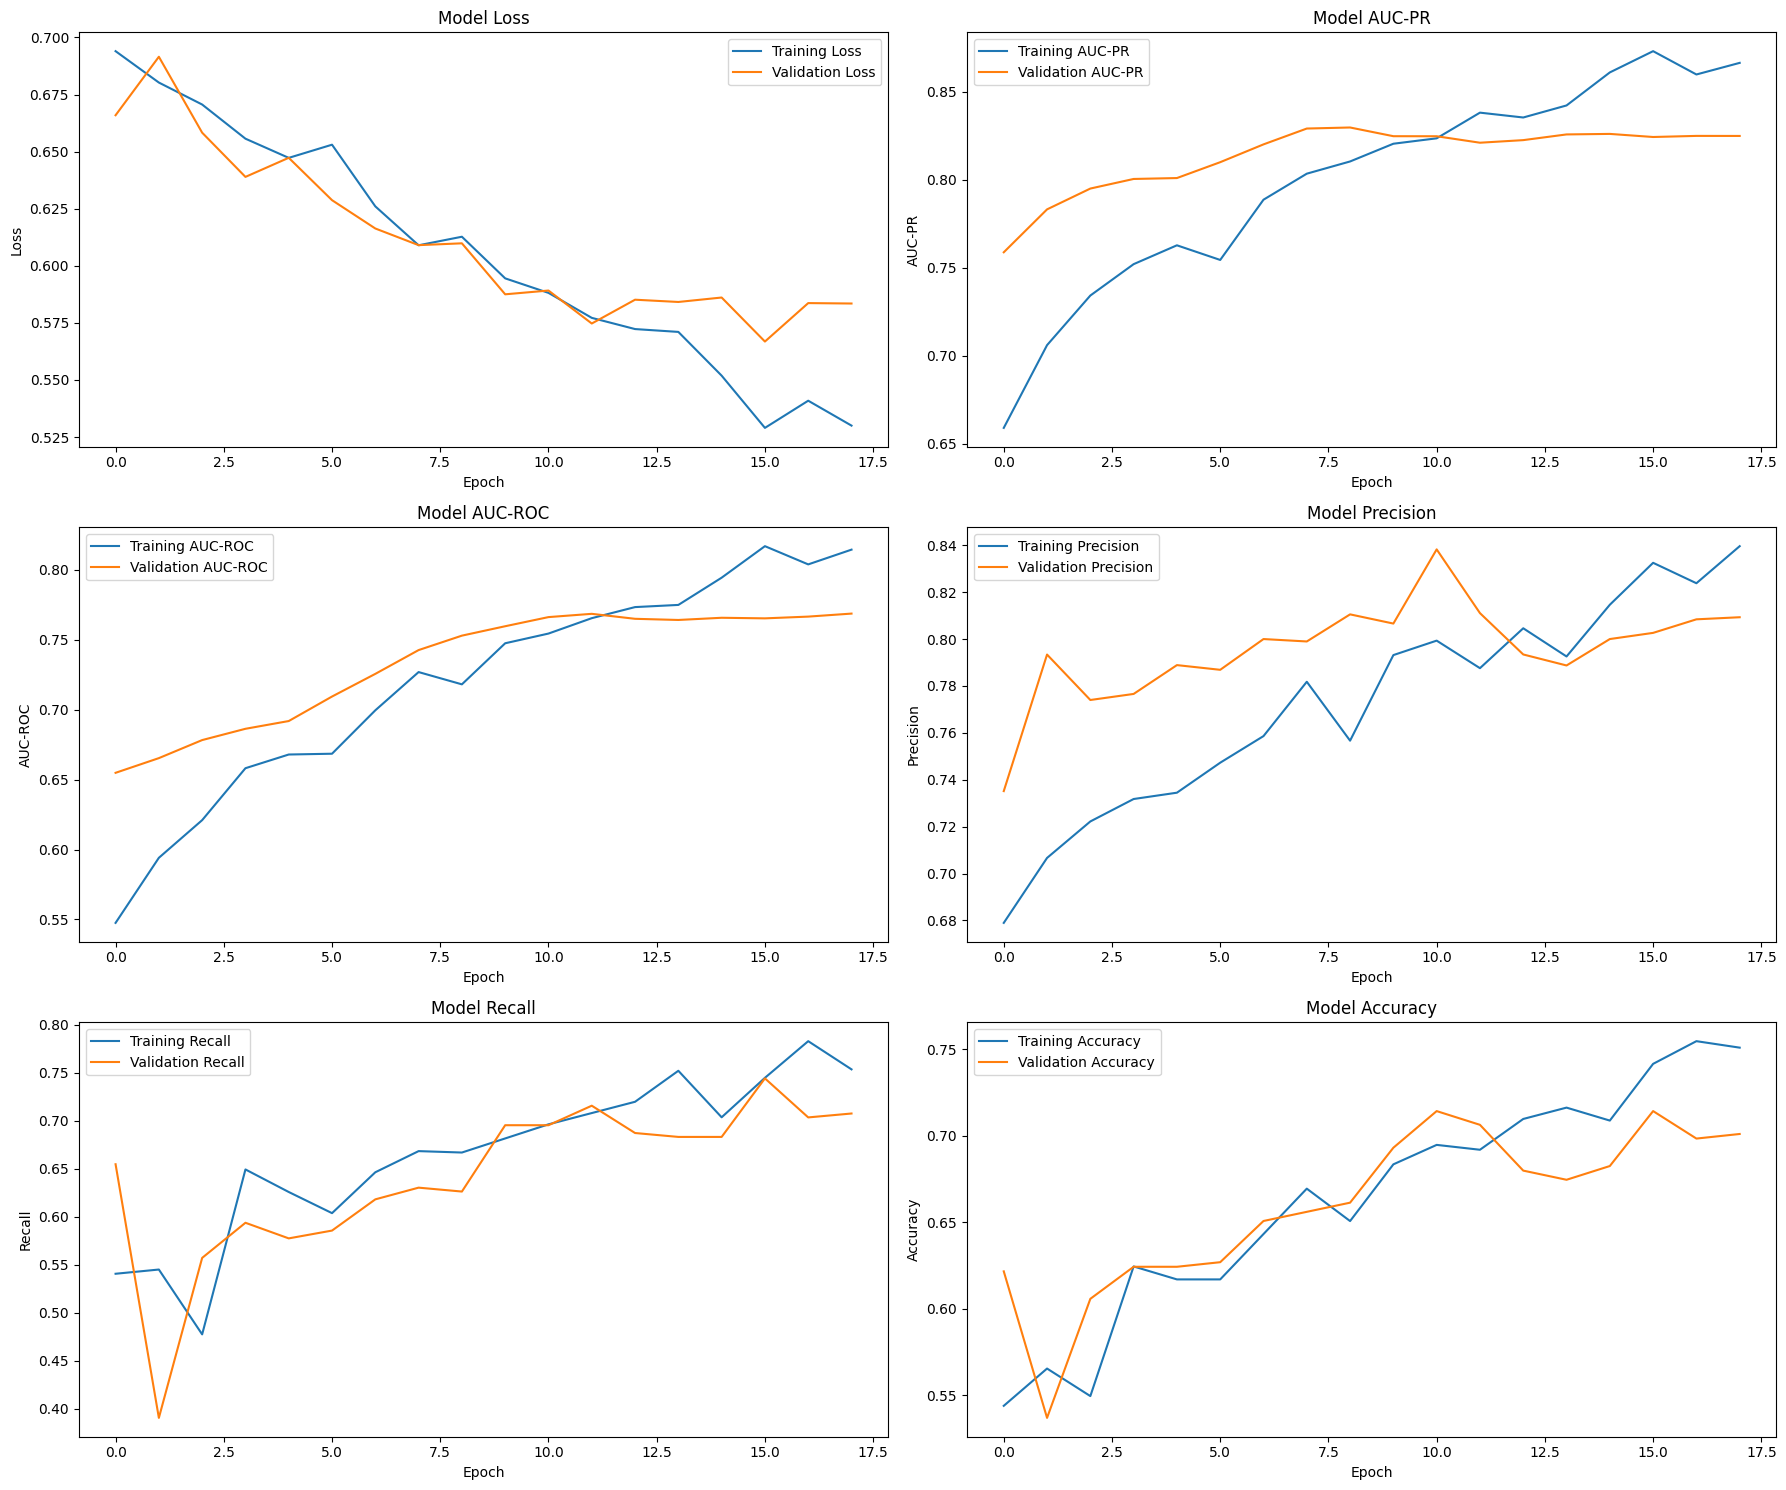

<Figure size 640x480 with 0 Axes>

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes[0, 0].plot(history['loss'], label='Training Loss')
axes[0, 0].plot(history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

if 'auc_pr' in history and 'val_auc_pr' in history:
    axes[0, 1].plot(history['auc_pr'], label='Training AUC-PR')
    axes[0, 1].plot(history['val_auc_pr'], label='Validation AUC-PR')
    axes[0, 1].set_title('Model AUC-PR')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC-PR')
    axes[0, 1].legend()
else:
    axes[0, 1].set_visible(False)

if 'auc_roc' in history and 'val_auc_roc' in history:
    axes[1, 0].plot(history['auc_roc'], label='Training AUC-ROC')
    axes[1, 0].plot(history['val_auc_roc'], label='Validation AUC-ROC')
    axes[1, 0].set_title('Model AUC-ROC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC-ROC')
    axes[1, 0].legend()
else:
    axes[1, 0].set_visible(False)

if 'precision' in history and 'val_precision' in history:
    axes[1, 1].plot(history['precision'], label='Training Precision')
    axes[1, 1].plot(history['val_precision'], label='Validation Precision')
    axes[1, 1].set_title('Model Precision')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend()
else:
    axes[1, 1].set_visible(False)

if 'recall' in history and 'val_recall' in history:
    axes[2, 0].plot(history['recall'], label='Training Recall')
    axes[2, 0].plot(history['val_recall'], label='Validation Recall')
    axes[2, 0].set_title('Model Recall')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Recall')
    axes[2, 0].legend()
else:
    axes[2, 0].set_visible(False)

if 'accuracy' in history and 'val_accuracy' in history:
    axes[2, 1].plot(history['accuracy'], label='Training Accuracy')
    axes[2, 1].plot(history['val_accuracy'], label='Validation Accuracy')
    axes[2, 1].set_title('Model Accuracy')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Accuracy')
    axes[2, 1].legend()
else:
    axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()

# Save the main plot
plt.savefig(MODEL_RESULTS_FOLDER / f'training_history.png', dpi=300, bbox_inches='tight')

In [21]:
y_pred_proba_val = model.predict([X_val_uni_left, X_val_uni_right])
best_threshold, stats = pick_threshold(y_val, y_pred_proba_val.flatten(), method="macro")
print(f"Best threshold: {best_threshold}")
for k, v in stats.items():
    print(f"Best {k}: {v}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 311ms/step
Best threshold: 0.38735565543174744
Best macro_f1: 0.7163636363636363


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.7030
Test AUC-ROC : 0.6422
=== Threshold Dependent Metrics ===
=== Threshold: 0.39 ===
Test Accuracy : 0.6431
Test F1-Macro Score : 0.6019
Test Precision : 0.6782
Test Recall : 0.7902

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.68      0.79      0.73       224
 Not Injured       0.56      0.41      0.47       143

    accuracy                           0.64       367
   macro avg       0.62      0.60      0.60       367
weighted avg       0.63      0.64      0.63       367



<Figure size 640x480 with 0 Axes>

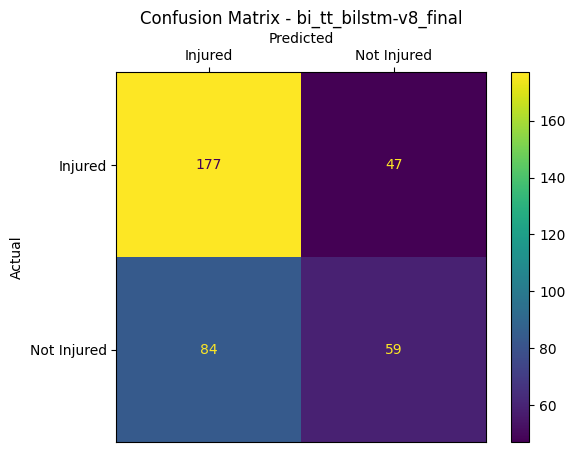

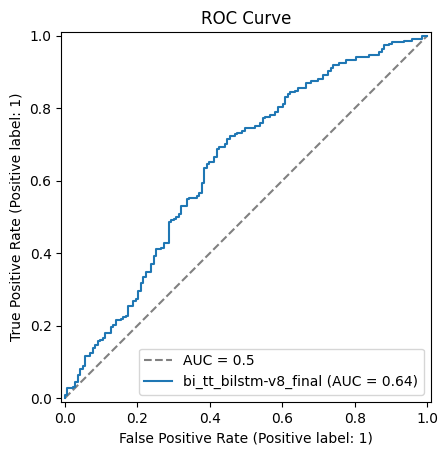

<Figure size 640x480 with 0 Axes>

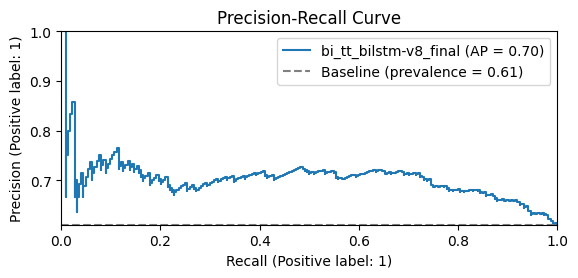

In [22]:
pred = BilateralPredictor(model)
test_summary = model_test_summary(model, [X_test_uni_left, X_test_uni_right], y_test, threshold=best_threshold, predictor=pred)

In [23]:
# Save the trained model
if SAVE_MODEL:
    model_loader.save_keras_model_to_disk()
    
    # Save scalers for future use
    scalers = {
        'timeseries_scaler': scaler_ts,
    }
    model_loader.save_scalers_to_disk(scalers)

    # Save training results
    results = {
        'test_accuracy': float(test_summary['accuracy']),
        'test_f1': float(test_summary['f1']),
        'tes_avg_precision': float(test_summary['auc_pr']),
        'test_auc_roc': float(test_summary['auc_roc']),
        'test_precision': float(test_summary['precision']),
        'test_recall': float(test_summary['recall']),   
        'test_prevalence': float(test_summary['prevalence']),
        'threshold': float(test_summary['threshold']),
        'model_name': MODEL_NAME,
        'training_params': {
            "epochs": model.history.params['epochs'],
            'epochs_run': len(model.history.epoch),
            'history': model.history.history,
            'batch_size': BATCH_SIZE,
            'learning_rate': float(model.optimizer.learning_rate.numpy()),
            'dropout_rate': next((layer.rate for layer in model.layers if hasattr(layer, 'rate')), "N/A"),
            'class_weights': class_weight_dict
        }
    }
    model_loader.save_results_to_disk(results)

    print(f"Model and results saved!")

Model and results saved!


## Model Explainability

Let's analyze feature importance using gradient-based saliency maps to understand which features and time points are most important for the model's predictions.


In [24]:
from core.evaluation import (
    compute_timeseries_saliency,
    plot_timeseries_saliency,
    analyze_sample_saliency,
    get_unilateral_feature_names
)

Left Side Analysis
Analyzing injured sample (index 0) and healthy sample (index 5)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Model predictions:
  Injured sample (true=1): 0.6609
  Healthy sample (true=0): 0.7220

Plotting saliency for injured sample (Left side)...


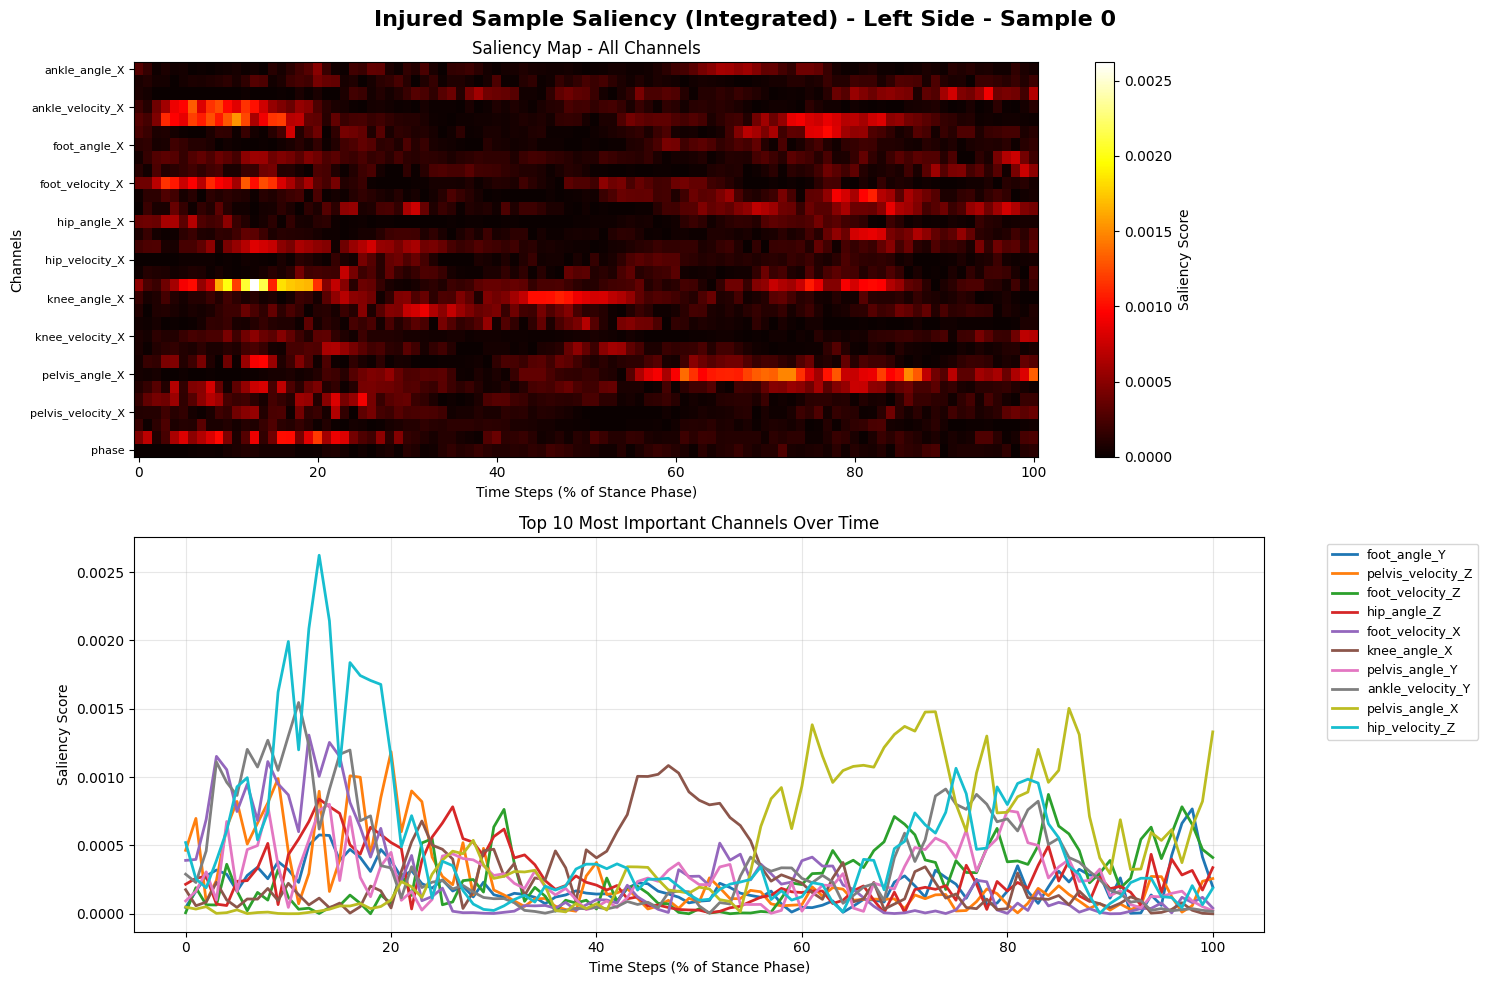


Plotting saliency for healthy sample (Left side)...


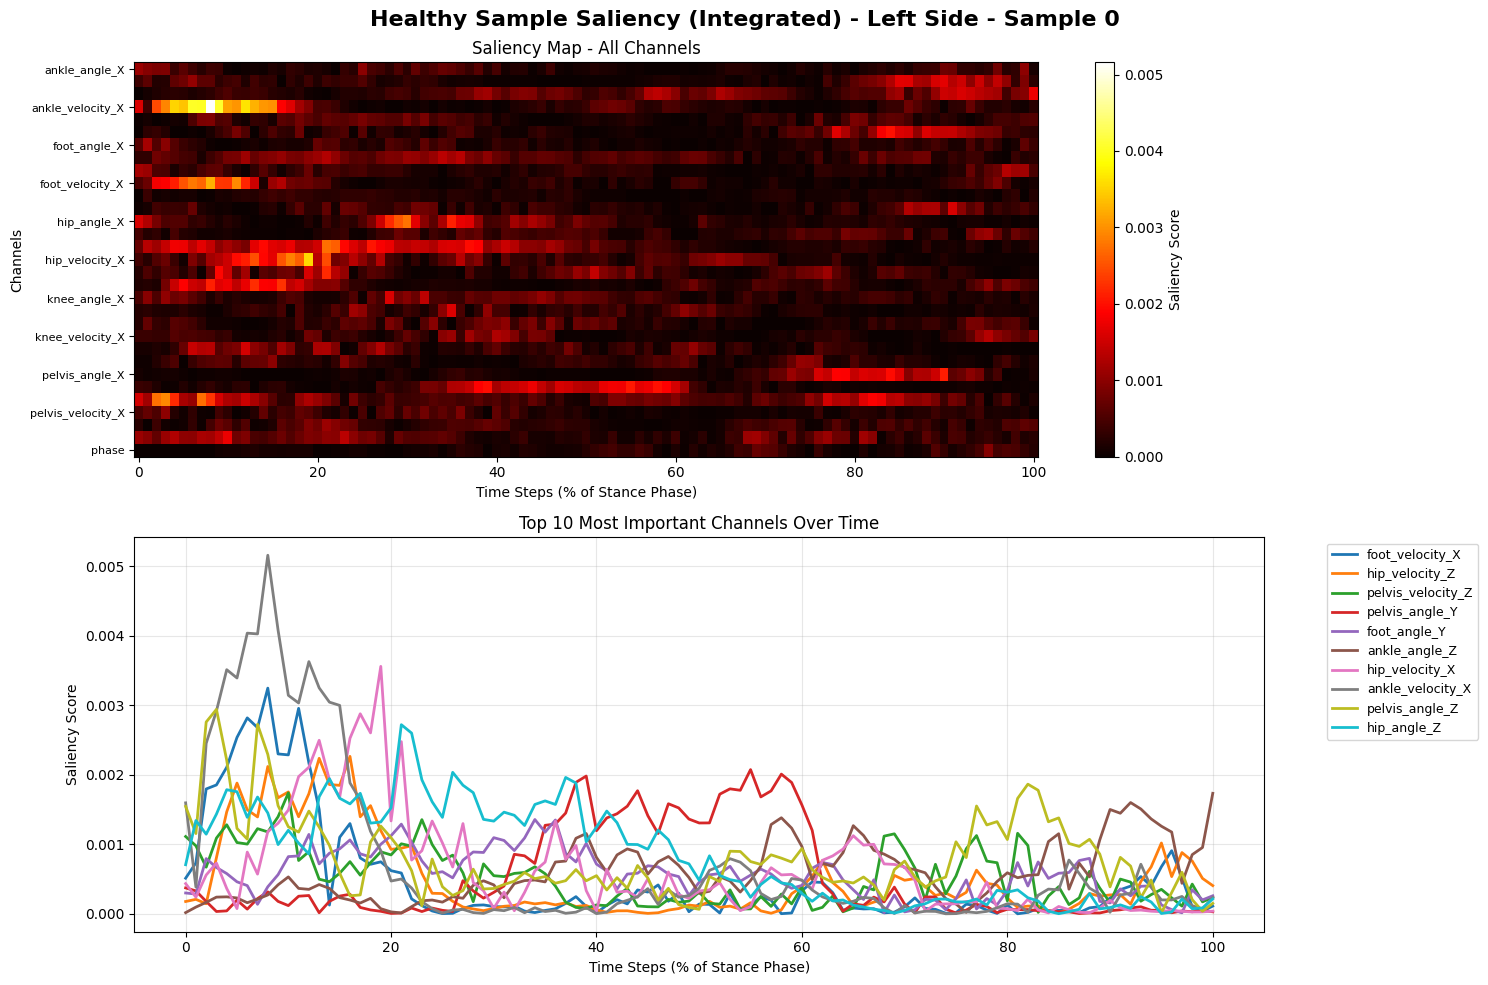


Top 5 features for injured sample:
  1. hip_velocity_Z: 0.0005
  2. pelvis_angle_X: 0.0005
  3. ankle_velocity_Y: 0.0004
  4. pelvis_angle_Y: 0.0003
  5. knee_angle_X: 0.0003

Top 5 features for healthy sample:
  1. hip_angle_Z: 0.0008
  2. pelvis_angle_Z: 0.0008
  3. ankle_velocity_X: 0.0007
  4. hip_velocity_X: 0.0006
  5. ankle_angle_Z: 0.0006


In [25]:
print("Left Side Analysis")
print("="*50)
l_feature_names = get_unilateral_feature_names(channels, side="L")
l_saliency = compute_timeseries_saliency(model, [X_test_uni_left, X_test_uni_right])
l_results = analyze_sample_saliency(model, [X_test_uni_left, X_test_uni_right], y_test, l_feature_names)

Right Side Analysis
Analyzing injured sample (index 0) and healthy sample (index 5)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Model predictions:
  Injured sample (true=1): 0.6609
  Healthy sample (true=0): 0.7220

Plotting saliency for injured sample (Left side)...


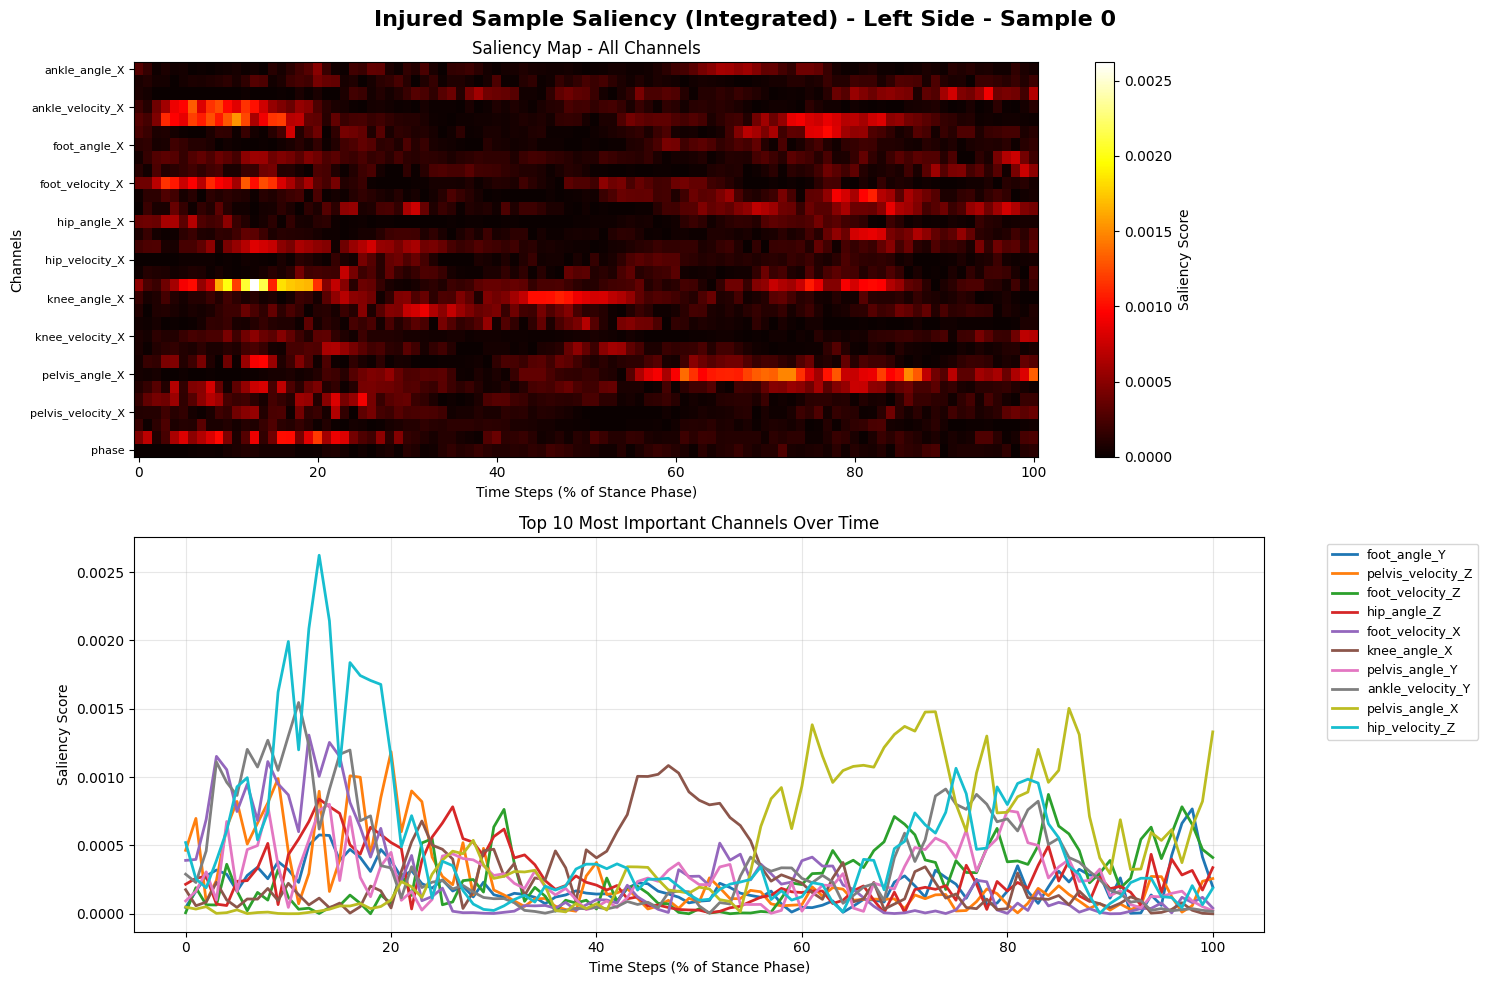


Plotting saliency for healthy sample (Left side)...


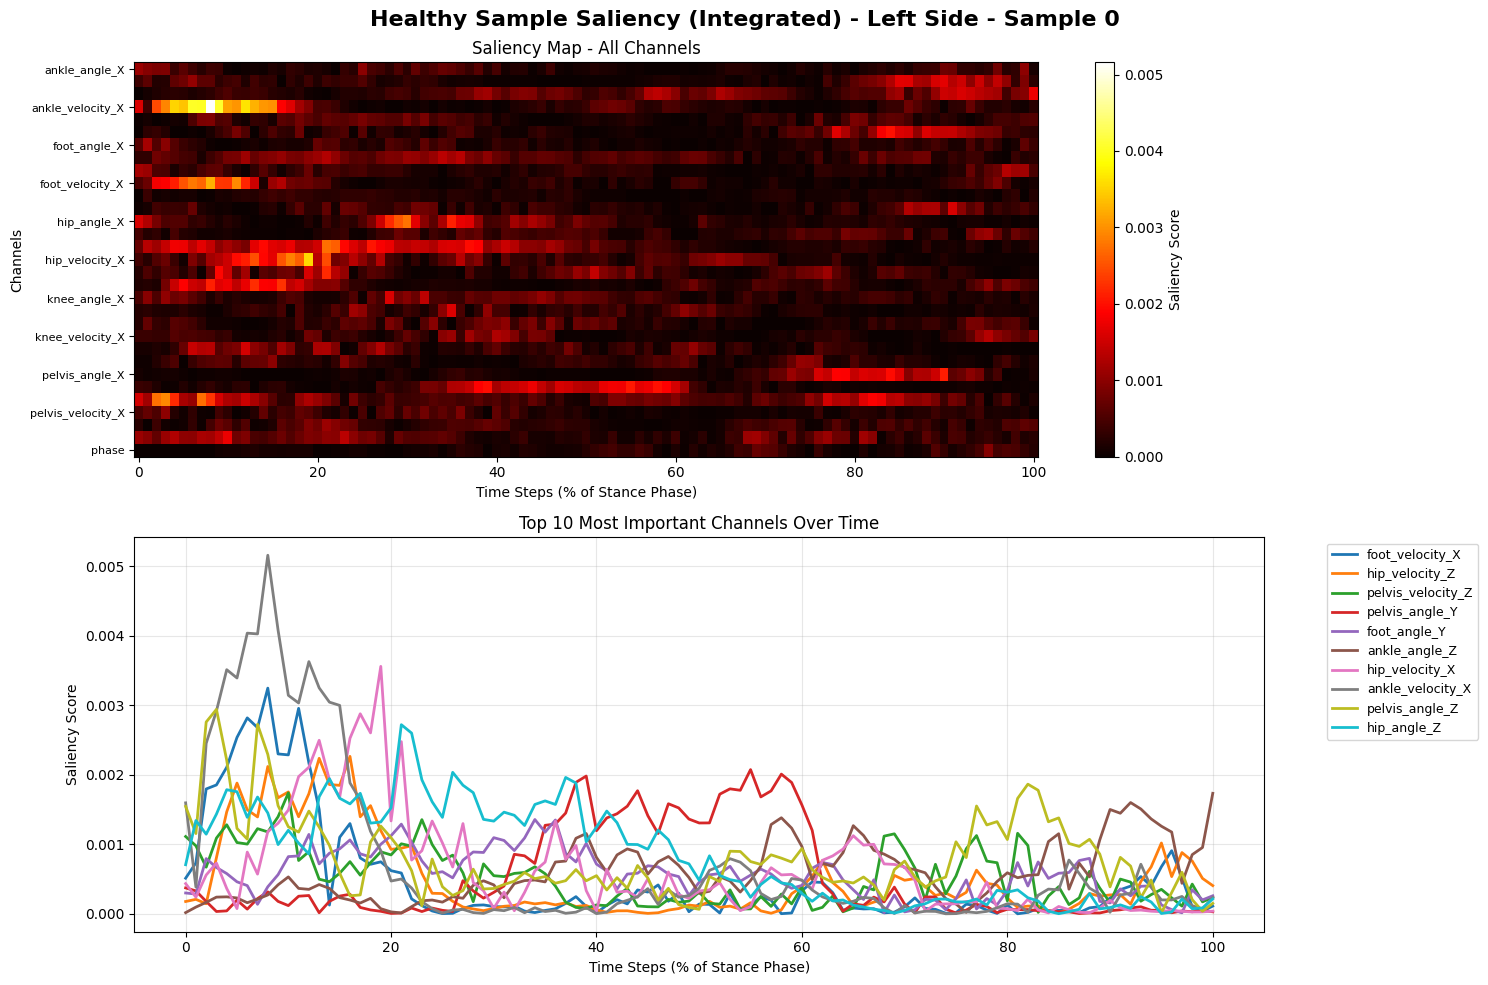


Top 5 features for injured sample:
  1. hip_velocity_Z: 0.0005
  2. pelvis_angle_X: 0.0005
  3. ankle_velocity_Y: 0.0004
  4. pelvis_angle_Y: 0.0003
  5. knee_angle_X: 0.0003

Top 5 features for healthy sample:
  1. hip_angle_Z: 0.0008
  2. pelvis_angle_Z: 0.0008
  3. ankle_velocity_X: 0.0007
  4. hip_velocity_X: 0.0006
  5. ankle_angle_Z: 0.0006


In [26]:
print("Right Side Analysis")
print("="*50)
r_feature_names = get_unilateral_feature_names(channels, side="R")
r_saliency = compute_timeseries_saliency(model, [X_test_uni_left, X_test_uni_right])
r_results = analyze_sample_saliency(model, [X_test_uni_left, X_test_uni_right], y_test, r_feature_names)